# Exploratory Data Analysis (EDA)

## Country-Level Economic Stress Monitoring and Predictive Analytics System

### Purpose

The purpose of this Exploratory Data Analysis (EDA) is to investigate global economic stress patterns using macroeconomic, demographic, and food security indicators. The analysis aims to uncover trends, relationships, regional differences, and key drivers of economic vulnerability across countries.

### Primary Analytical Question

**Which countries exhibit higher levels of economic stress based on inflation, GDP growth, unemployment, income level, population characteristics, and food and agricultural indicators?**

---

## Analysis Objectives

The analysis will focus on understanding the factors that contribute to economic stress and identifying patterns that can support economic risk assessment and decision-making.

---

## Key Questions to be Answered

### 1. Economic Stress Assessment
- Which countries have the highest economic stress levels in recent years?
- Which countries have the lowest economic stress levels?
- How is economic stress distributed globally?

### 2. Regional and Income Group Analysis
- How does economic stress vary across geographic regions?
- How does economic stress differ among income groups?
- Which regions are most vulnerable to economic stress?

### 3. Macroeconomic Analysis
- What is the relationship between inflation and GDP growth?
- How does unemployment influence economic stress?
- Which macroeconomic indicators have the strongest relationship with economic stress?

### 4. Food Security Analysis
- How do food production indicators relate to economic stress?
- Does food pressure increase economic vulnerability?
- Which food security indicators show the strongest correlation with economic stress?

### 5. Country Segmentation Analysis
- Which clusters of countries share similar economic and agricultural characteristics?
- What common patterns exist within each cluster?

### 6. Predictive Analytics
- Can future economic stress levels be predicted using historical economic and food security indicators?
- Which variables contribute most to predictive performance?

---

## Expected Deliverables

The EDA will produce:

- Country-level economic stress rankings
- Regional and income-group comparisons
- Trend analysis and visualizations
- Correlation and relationship analysis
- Food security insights
- Country segmentation insights
- Data-driven recommendations
- Inputs for predictive modeling and dashboard development

---

## Dataset

**Primary Dataset:** `country_year_indicators.csv`

**Supporting Datasets:**
- `country_metadata.csv`
- `economic_stress_score.csv`
- `indicator_dictionary.csv`

In [2]:
# =====================================================
# LOAD DATASET
# =====================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

country_year = pd.read_csv("C:/Users/saksh/Desktop/country-economic-stress-analysis/data/country_year_indicators.csv")

## 1. Dataset Overview

This section provides a high-level summary of the dataset, including its size, coverage, and key characteristics. Understanding the dataset structure helps establish context for subsequent analyses and ensures that the data is suitable for answering the project's analytical questions.

In [3]:
# =====================================================
# DATASET SUMMARY
# =====================================================

summary = pd.DataFrame({
    'Metric': [
        'Total Records',
        'Total Columns',
        'Total Countries',
        'Total Regions',
        'Total Income Groups',
        'Start Year',
        'End Year'
    ],
    'Value': [
        country_year.shape[0],
        country_year.shape[1],
        country_year['country_name'].nunique(),
        country_year['region'].nunique(),
        country_year['income_group'].nunique(),
        country_year['year'].min(),
        country_year['year'].max()
    ]
})

summary

,Metric,Value
0,Total Records,14322
1,Total Columns,18
2,Total Countries,217
3,Total Regions,7
4,Total Income Groups,5
5,Start Year,1960
6,End Year,2025


In [4]:
# =====================================================
# DATASET DIMENSIONS
# =====================================================

print(f"Rows: {country_year.shape[0]:,}")
print(f"Columns: {country_year.shape[1]}")

Rows: 14,322
Columns: 18


### Dataset Coverage by Year

This analysis evaluates the number of country observations available across years and helps identify periods with stronger or weaker data availability.

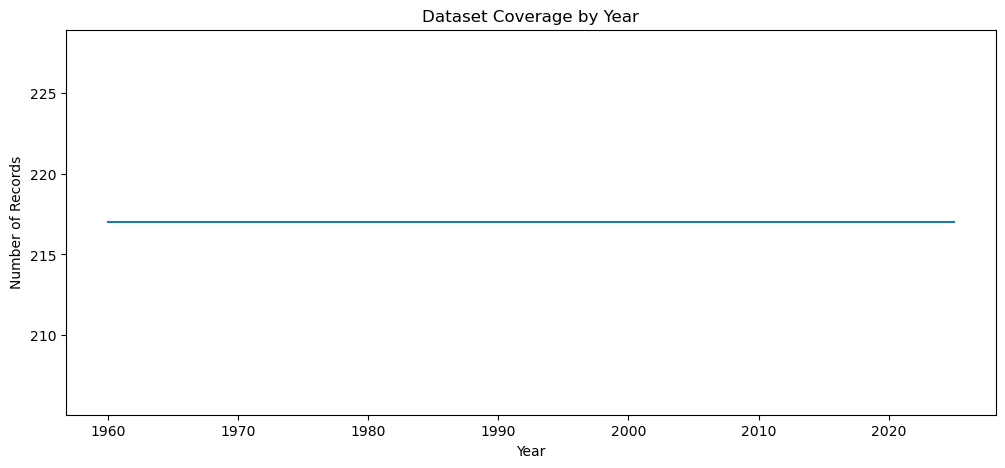

In [8]:
# =====================================================
# COVERAGE BY YEAR
# =====================================================

year_coverage = (
    country_year['year']
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(12,5))

plt.plot(
    year_coverage.index,
    year_coverage.values
)

plt.title('Dataset Coverage by Year')
plt.xlabel('Year')
plt.ylabel('Number of Records')

plt.show()

### Dataset Coverage by Region

This analysis evaluates the distribution of records across geographic regions represented in the dataset.

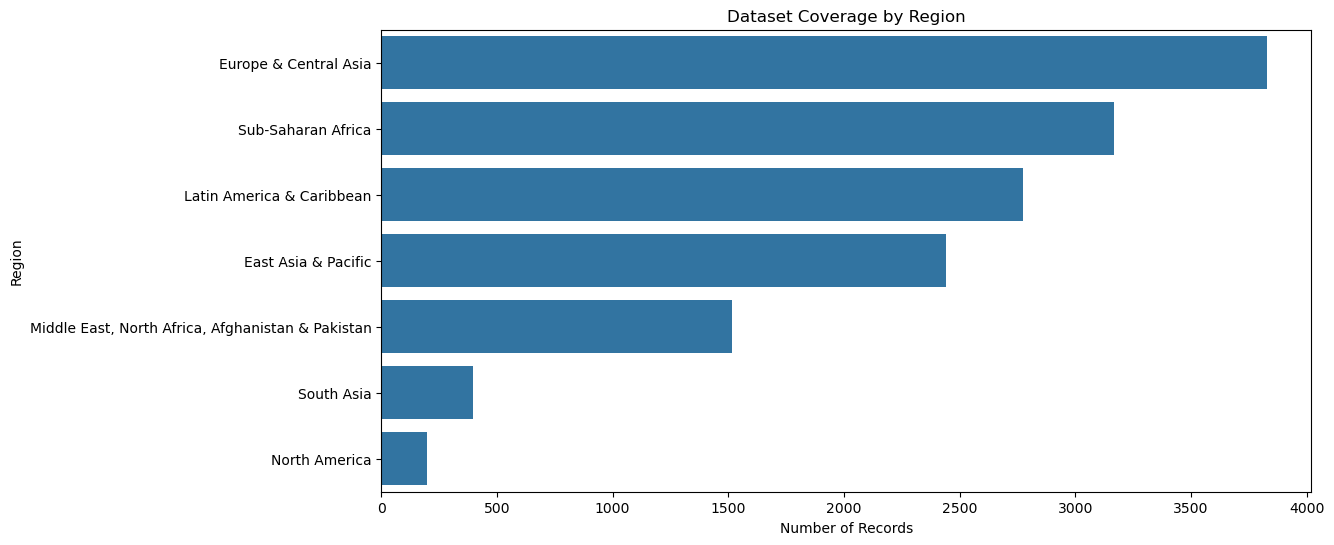

In [9]:
# =====================================================
# COVERAGE BY REGION
# =====================================================

region_counts = (
    country_year['region']
    .value_counts()
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=region_counts.values,
    y=region_counts.index
)

plt.title('Dataset Coverage by Region')
plt.xlabel('Number of Records')
plt.ylabel('Region')

plt.show()

### Dataset Coverage by Income Group

This analysis evaluates the representation of countries across different World Bank income classifications.

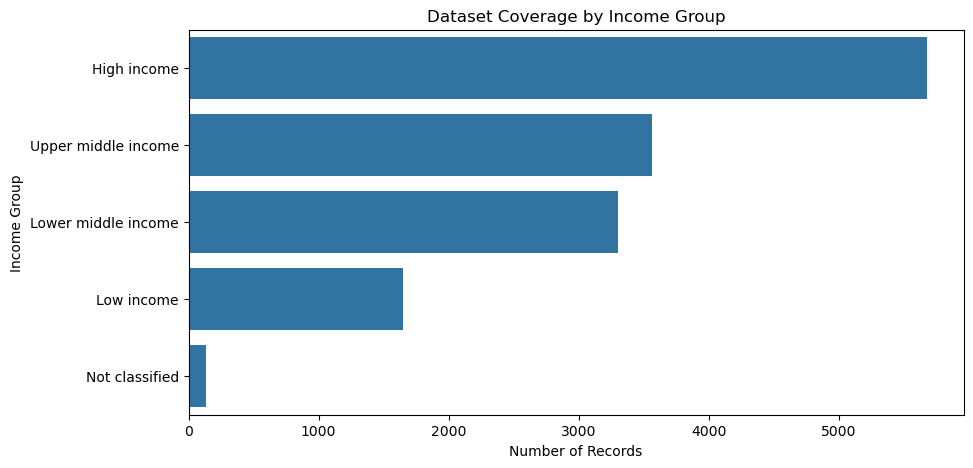

In [10]:
# =====================================================
# COVERAGE BY INCOME GROUP
# =====================================================

income_counts = (
    country_year['income_group']
    .value_counts()
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=income_counts.values,
    y=income_counts.index
)

plt.title('Dataset Coverage by Income Group')
plt.xlabel('Number of Records')
plt.ylabel('Income Group')

plt.show()

### Key Observations

- The dataset contains historical observations spanning from 1960 to 2025.
- Data is available across multiple geographic regions and income groups.
- Coverage varies across years, reflecting differences in historical reporting availability.
- The dataset provides sufficient geographic and temporal coverage to support country-level, regional, and global economic stress analysis.

## 2. Economic Stress Distribution

This section examines the distribution of Economic Stress Scores across all observations in the dataset. Understanding the overall distribution helps identify common stress levels, variability, and the prevalence of high-stress conditions across countries and years.

In [11]:
# =====================================================
# ECONOMIC STRESS SCORE SUMMARY
# =====================================================

country_year['economic_stress_score'].describe()

count    12762.000000
mean        49.822761
std         17.273854
min          0.000000
25%         37.902500
50%         49.620000
75%         61.607500
max        100.000000
Name: economic_stress_score, dtype: float64

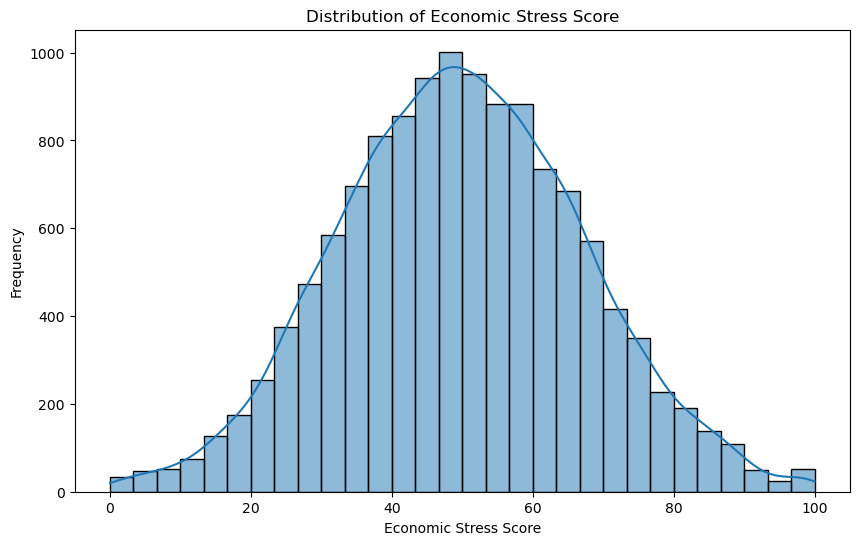

In [15]:
# =====================================================
# ECONOMIC STRESS SCORE DISTRIBUTION
# =====================================================

plt.figure(figsize=(10,6))

sns.histplot(
    country_year['economic_stress_score'],
    bins=30,
    kde=True
)

plt.title('Distribution of Economic Stress Score')
plt.xlabel('Economic Stress Score')
plt.ylabel('Frequency')

plt.show()

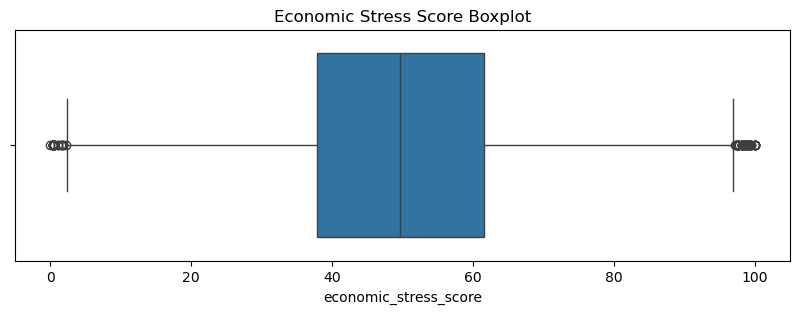

In [16]:
# =====================================================
# ECONOMIC STRESS SCORE BOXPLOT
# =====================================================

plt.figure(figsize=(10,3))

sns.boxplot(
    x=country_year['economic_stress_score']
)

plt.title('Economic Stress Score Boxplot')

plt.show()

In [17]:
# =====================================================
# STRESS CATEGORY
# =====================================================

bins = [0, 25, 50, 75, 100]

labels = [
    'Low',
    'Moderate',
    'High',
    'Severe'
]

country_year['stress_category'] = pd.cut(
    country_year['economic_stress_score'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

country_year['stress_category'].value_counts()

stress_category
Moderate    5587
High        5288
Severe       967
Low          920
Name: count, dtype: int64

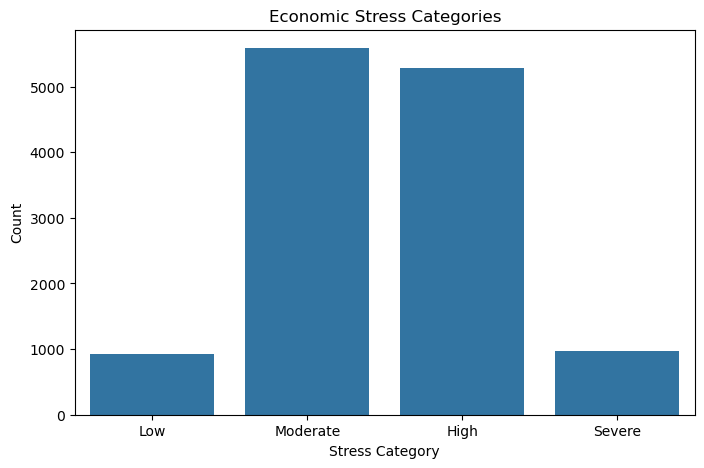

In [18]:
# =====================================================
# STRESS CATEGORY DISTRIBUTION
# =====================================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=country_year,
    x='stress_category',
    order=['Low','Moderate','High','Severe']
)

plt.title('Economic Stress Categories')

plt.xlabel('Stress Category')
plt.ylabel('Count')

plt.show()

### Key Findings

- Economic stress is predominantly concentrated within the Moderate and High categories.
- Moderate stress accounts for approximately 43.8% of all observations.
- High stress accounts for approximately 41.4% of all observations.
- Severe stress represents approximately 7.6% of observations, indicating a smaller group of highly vulnerable country-year combinations.
- Low stress accounts for approximately 7.2% of observations.
- More than 85% of observations fall within the Moderate or High stress categories, suggesting that economic stress is a widespread global phenomenon rather than being limited to a small number of countries.

## 3. Highest Economic Stress Countries (2020–2025)

This section identifies countries with the highest average Economic Stress Scores during the period 2020–2025. Focusing on recent years provides a more relevant view of current economic vulnerability and stress conditions.

In [19]:
# =====================================================
# RECENT PERIOD DATASET
# =====================================================

recent_data = country_year[
    country_year['year'].between(2020, 2025)
].copy()

print("Records:", recent_data.shape[0])

Records: 1302


In [20]:
# =====================================================
# TOP 10 MOST STRESSED COUNTRIES
# =====================================================

top_stress = (
    recent_data
    .groupby('country_name')['economic_stress_score']
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top_stress

,country_name,economic_stress_score
0,Haiti,89.961667
1,Sudan,88.492000
2,"Yemen, Rep.",87.135000
3,"Somalia, Fed. Rep.",84.938333
4,Syrian Arab Republic,84.123333
5,Lesotho,83.573333
6,Lebanon,81.818000
7,Eswatini,81.578333
8,Angola,81.036667
9,Sao Tome and Principe,76.840000


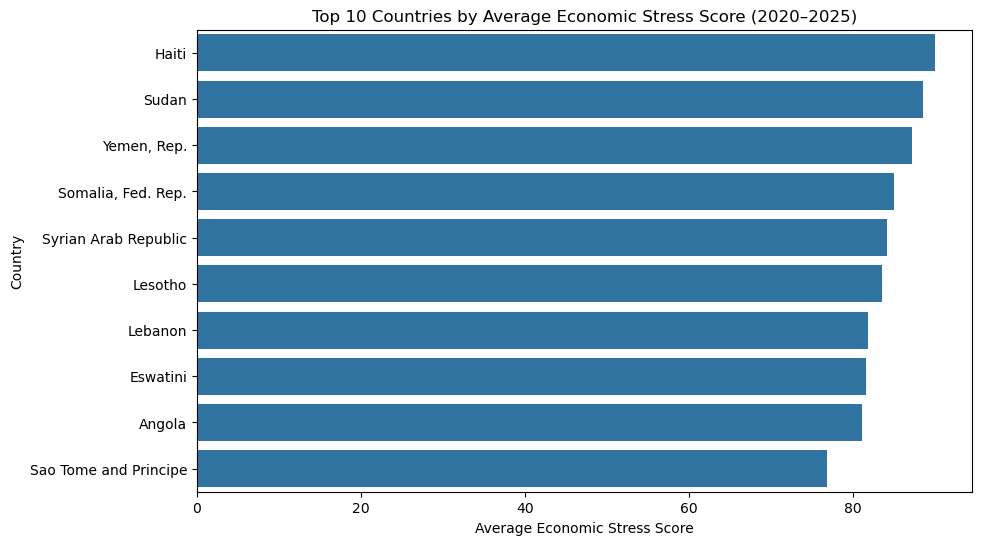

In [21]:
# =====================================================
# TOP 10 MOST STRESSED COUNTRIES
# =====================================================

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_stress,
    x='economic_stress_score',
    y='country_name'
)

plt.title('Top 10 Countries by Average Economic Stress Score (2020–2025)')
plt.xlabel('Average Economic Stress Score')
plt.ylabel('Country')

plt.show()

In [23]:
# =====================================================
# TOP 10 LEAST STRESSED COUNTRIES
# =====================================================

lowest_stress = (
    recent_data
    .groupby('country_name')['economic_stress_score']
    .mean()
    .sort_values()
    .head(10)
    .reset_index()
)

lowest_stress

,country_name,economic_stress_score
0,Liechtenstein,0.482500
1,Monaco,13.318000
2,Qatar,15.605000
3,Bahrain,15.776667
4,United Arab Emirates,19.145000
5,Bermuda,21.890000
6,Turks and Caicos Islands,23.198000
7,Cayman Islands,23.450000
8,Aruba,23.476000
9,"Macao SAR, China",23.741667


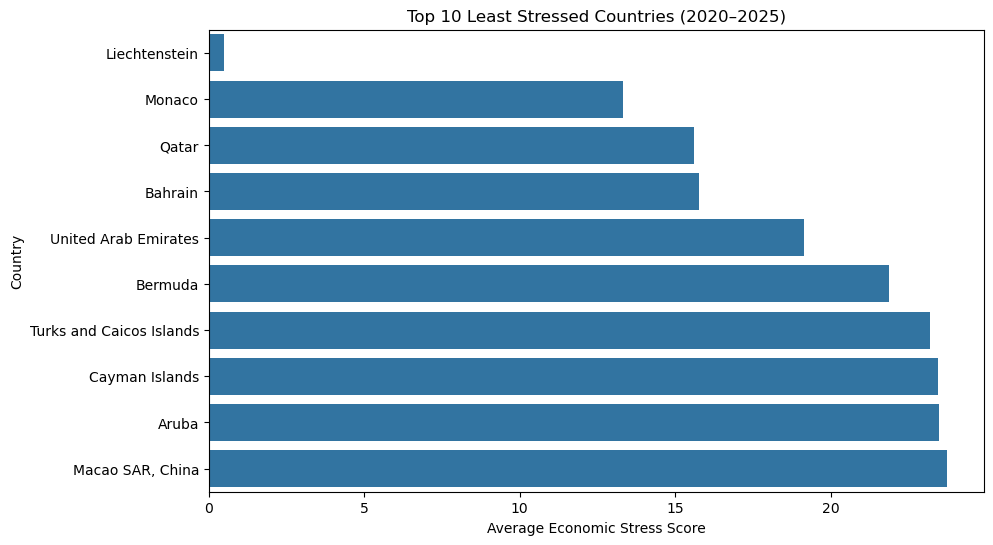

In [24]:
# =====================================================
# TOP 10 LEAST STRESSED COUNTRIES
# =====================================================

plt.figure(figsize=(10,6))

sns.barplot(
    data=lowest_stress,
    x='economic_stress_score',
    y='country_name'
)

plt.title('Top 10 Least Stressed Countries (2020–2025)')
plt.xlabel('Average Economic Stress Score')
plt.ylabel('Country')

plt.show()

In [25]:
# =====================================================
# RECENT STRESS CATEGORY DISTRIBUTION
# =====================================================

recent_data['stress_category'].value_counts()

stress_category
Moderate    520
High        492
Severe      117
Low         115
Name: count, dtype: int64

### Key Findings

#### Highest Economic Stress Countries (2020–2025)

The countries with the highest average Economic Stress Scores during the period 2020–2025 are:

- Haiti
- Sudan
- Yemen
- Somalia
- Syrian Arab Republic
- Lesotho
- Lebanon
- Eswatini
- Angola
- Sao Tome and Principe

These countries consistently experienced elevated levels of economic vulnerability, reflecting challenges such as inflationary pressure, weak economic growth, unemployment, income vulnerability, and food security concerns.

#### Lowest Economic Stress Countries (2020–2025)

The countries with the lowest average Economic Stress Scores during the same period are:

- Liechtenstein
- Monaco
- Qatar
- Bahrain
- United Arab Emirates
- Bermuda
- Turks and Caicos Islands
- Cayman Islands
- Aruba
- Macao SAR, China

These countries generally demonstrate stronger economic stability, higher income levels, and lower vulnerability to economic and food-related stress factors.

#### Overall Observation

A clear contrast exists between high-stress countries, which are predominantly lower-income and economically vulnerable nations, and low-stress countries, which are generally high-income economies with stronger economic resilience.

## 4. Regional Analysis

This section examines how Economic Stress Scores differ across geographic regions. Regional comparisons help identify areas experiencing higher economic vulnerability and provide insights into broader economic patterns.

In [26]:
# =====================================================
# AVERAGE ECONOMIC STRESS BY REGION
# =====================================================

region_stress = (
    recent_data
    .groupby('region')['economic_stress_score']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

region_stress

,region,economic_stress_score
0,Sub-Saharan Africa,58.022772
1,"Middle East, North Africa, Afghanistan & Pakistan",53.828162
2,Latin America & Caribbean,50.797155
3,South Asia,49.995833
4,Europe & Central Asia,45.911550
5,East Asia & Pacific,42.325120
6,North America,35.587059


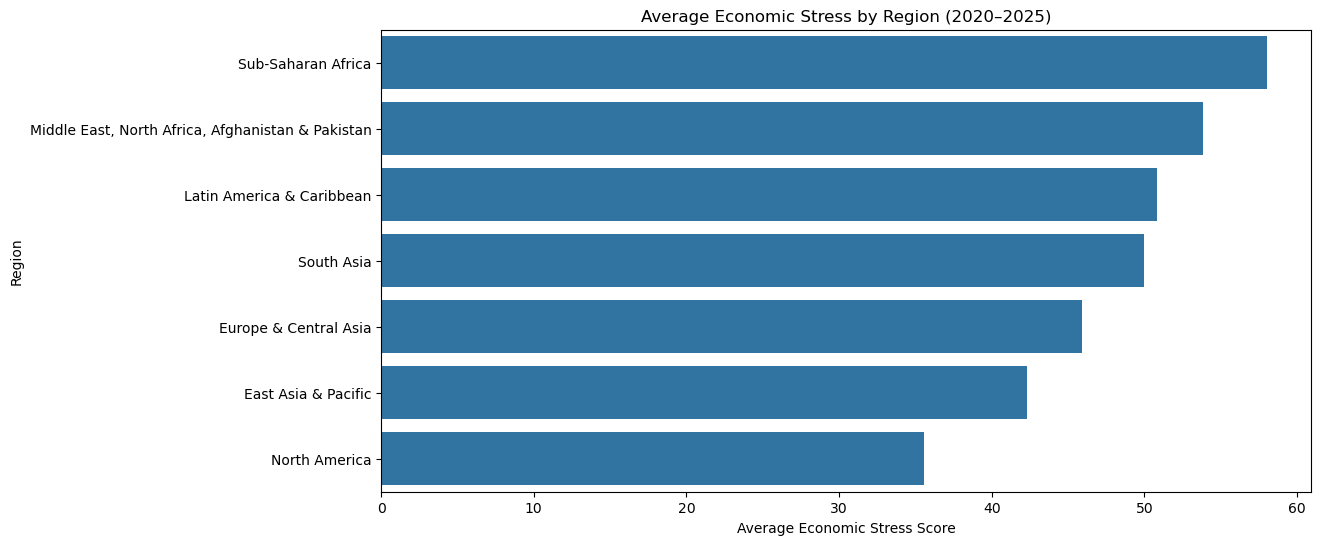

In [27]:
# =====================================================
# REGION VS ECONOMIC STRESS
# =====================================================

plt.figure(figsize=(12,6))

sns.barplot(
    data=region_stress,
    x='economic_stress_score',
    y='region'
)

plt.title('Average Economic Stress by Region (2020–2025)')
plt.xlabel('Average Economic Stress Score')
plt.ylabel('Region')

plt.show()

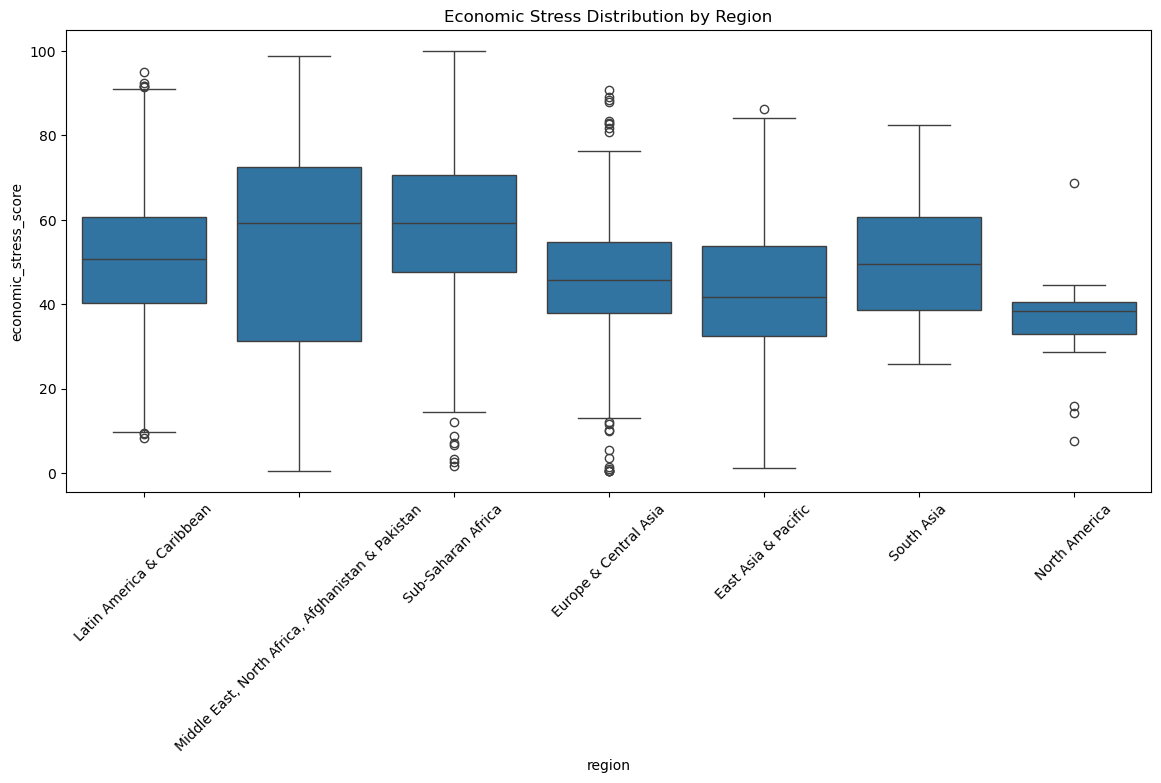

In [28]:
# =====================================================
# STRESS DISTRIBUTION BY REGION
# =====================================================

plt.figure(figsize=(14,6))

sns.boxplot(
    data=recent_data,
    x='region',
    y='economic_stress_score'
)

plt.xticks(rotation=45)

plt.title('Economic Stress Distribution by Region')

plt.show()

In [29]:
# =====================================================
# REGION RANKING
# =====================================================

region_stress.round(2)

,region,economic_stress_score
0,Sub-Saharan Africa,58.02
1,"Middle East, North Africa, Afghanistan & Pakistan",53.83
2,Latin America & Caribbean,50.80
3,South Asia,50.00
4,Europe & Central Asia,45.91
5,East Asia & Pacific,42.33
6,North America,35.59


### Key Findings

#### Regional Economic Stress Ranking (2020–2025)

Sub-Saharan Africa recorded the highest average Economic Stress Score (58.02), indicating the greatest level of economic vulnerability among all regions.

The Middle East, North Africa, Afghanistan & Pakistan region ranked second with an average score of 53.83, followed by Latin America & Caribbean (50.80) and South Asia (50.00).

Europe & Central Asia and East Asia & Pacific exhibited relatively lower stress levels, while North America recorded the lowest average Economic Stress Score (35.59).

#### Key Insights

- Sub-Saharan Africa appears to be the most economically vulnerable region during the 2020–2025 period.
- Regions with lower average income levels generally exhibit higher economic stress.
- North America demonstrates the strongest overall economic resilience among the regions analyzed.
- Economic stress varies significantly across regions, suggesting that geographic and structural economic factors play an important role in vulnerability levels.

## 5. Income Group Analysis

This section evaluates how Economic Stress Scores vary across World Bank income classifications. The analysis helps determine whether lower-income countries experience higher levels of economic stress compared to higher-income economies.

In [31]:
# =====================================================
# AVERAGE ECONOMIC STRESS BY INCOME GROUP
# =====================================================

income_stress = (
    recent_data
    .groupby('income_group')['economic_stress_score']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

income_stress.round(2)

,income_group,economic_stress_score
0,Low income,58.38
1,Lower middle income,55.82
2,Not classified,55.08
3,Upper middle income,53.46
4,High income,40.82


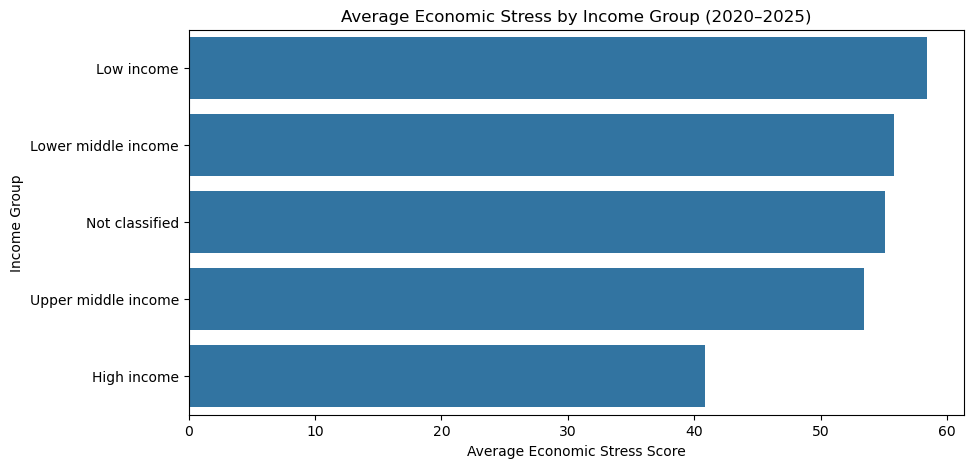

In [32]:
# =====================================================
# INCOME GROUP VS ECONOMIC STRESS
# =====================================================

plt.figure(figsize=(10,5))

sns.barplot(
    data=income_stress,
    x='economic_stress_score',
    y='income_group'
)

plt.title('Average Economic Stress by Income Group (2020–2025)')
plt.xlabel('Average Economic Stress Score')
plt.ylabel('Income Group')

plt.show()

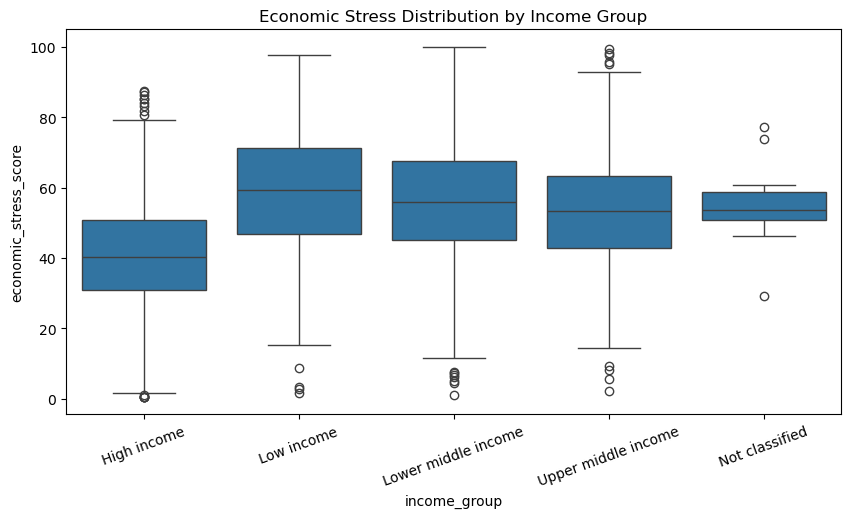

In [33]:
# =====================================================
# STRESS DISTRIBUTION BY INCOME GROUP
# =====================================================

plt.figure(figsize=(10,5))

sns.boxplot(
    data=recent_data,
    x='income_group',
    y='economic_stress_score'
)

plt.xticks(rotation=20)

plt.title('Economic Stress Distribution by Income Group')

plt.show()

In [34]:
# =====================================================
# COUNTRY COUNT BY INCOME GROUP
# =====================================================

recent_data.groupby('income_group')['country_name'].nunique().reset_index(name='Country Count')

,income_group,Country Count
0,High income,86
1,Low income,25
2,Lower middle income,50
3,Not classified,2
4,Upper middle income,54


### Key Findings

#### Economic Stress by Income Group (2020–2025)

Low-income countries recorded the highest average Economic Stress Score (58.38), followed by Lower Middle Income countries (55.82) and Upper Middle Income countries (53.46).

High-income countries exhibited the lowest average Economic Stress Score (40.82), indicating significantly lower levels of economic vulnerability.

#### Key Insights

- Economic stress generally decreases as income levels increase.
- Low-income economies appear to be the most vulnerable to macroeconomic and food security pressures.
- High-income countries demonstrate stronger resilience against economic shocks and stress factors.
- The results suggest a strong relationship between income vulnerability and overall economic stress.
- Income classification is likely to be a significant explanatory factor in future statistical and predictive analyses.

## 6. Inflation, GDP Growth, and Unemployment Analysis

This section examines the relationship between inflation, GDP growth, and unemployment to better understand the macroeconomic conditions associated with economic stress. The analysis explores correlations, distributions, and interactions among these key economic indicators.

In [35]:
# =====================================================
# MACROECONOMIC ANALYSIS DATASET
# =====================================================

macro_df = country_year[
    [
        'inflation',
        'gdp_growth',
        'unemployment',
        'economic_stress_score'
    ]
].dropna()

macro_df.shape

(5508, 4)

In [36]:
# =====================================================
# MACROECONOMIC SUMMARY
# =====================================================

macro_df.describe().T

,count,mean,std,min,25%,50%,75%,max
inflation,5508.0,23.255398,353.687957,-16.859691,1.904237,4.142654,8.609069,23773.131770
gdp_growth,5508.0,3.593204,6.260529,-64.047107,1.500000,3.735638,5.900001,149.972963
unemployment,5508.0,7.858560,5.884960,0.100000,3.591000,6.199000,10.587000,38.800000
economic_stress_score,5508.0,49.927259,14.172079,8.410000,39.730000,49.530000,59.715000,94.010000


In [37]:
# =====================================================
# CORRELATION MATRIX
# =====================================================

macro_corr = macro_df[
    [
        'inflation',
        'gdp_growth',
        'unemployment',
        'economic_stress_score'
    ]
].corr()

macro_corr

,inflation,gdp_growth,unemployment,economic_stress_score
inflation,1.000000,-0.065443,-0.005625,0.083920
gdp_growth,-0.065443,1.000000,-0.086972,-0.283687
unemployment,-0.005625,-0.086972,1.000000,0.496660
economic_stress_score,0.083920,-0.283687,0.496660,1.000000


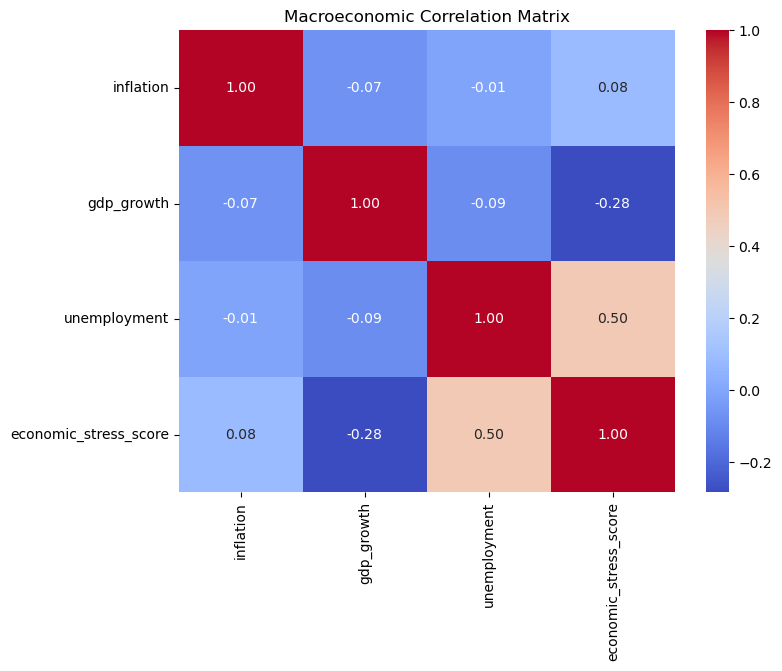

In [38]:
# =====================================================
# CORRELATION HEATMAP
# =====================================================

plt.figure(figsize=(8,6))

sns.heatmap(
    macro_corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Macroeconomic Correlation Matrix')

plt.show()

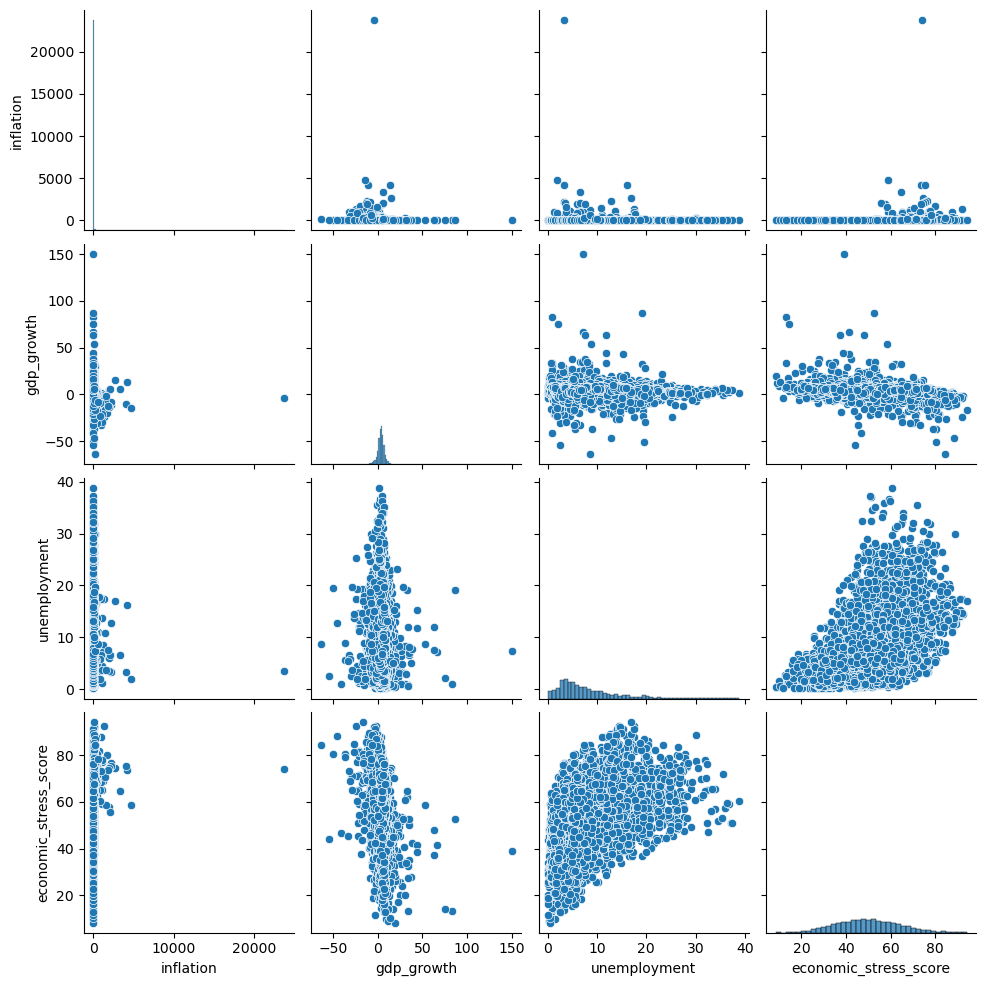

In [40]:
# =====================================================
# PAIRPLOT
# =====================================================

sns.pairplot(
    macro_df[
        [
            'inflation',
            'gdp_growth',
            'unemployment',
            'economic_stress_score'
        ]
    ]
)

plt.show()

In [41]:
# =====================================================
# CORRELATION WITH ECONOMIC STRESS
# =====================================================

macro_corr['economic_stress_score'].sort_values(
    ascending=False
)

economic_stress_score    1.000000
unemployment             0.496660
inflation                0.083920
gdp_growth              -0.283687
Name: economic_stress_score, dtype: float64

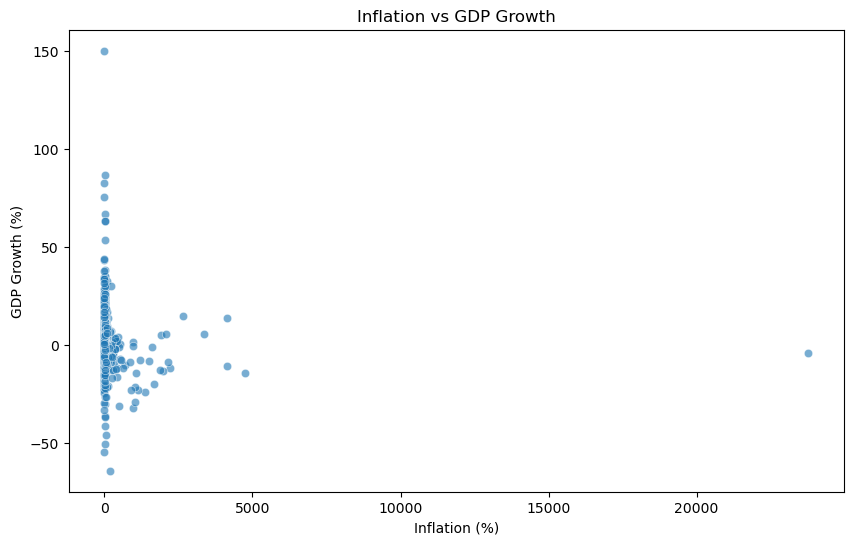

In [42]:
# =====================================================
# INFLATION VS GDP GROWTH
# =====================================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=macro_df,
    x='inflation',
    y='gdp_growth',
    alpha=0.6
)

plt.title('Inflation vs GDP Growth')

plt.xlabel('Inflation (%)')
plt.ylabel('GDP Growth (%)')

plt.show()

### Key Findings

#### Inflation and Economic Stress

Inflation exhibits a very weak positive correlation with Economic Stress Score (0.08). This suggests that inflation alone is not a strong predictor of overall economic stress across countries.

#### GDP Growth and Economic Stress

GDP Growth shows a weak negative correlation with Economic Stress Score (-0.28). Countries experiencing stronger economic growth tend to exhibit lower levels of economic stress, although the relationship is not particularly strong.

#### Unemployment and Economic Stress

Unemployment demonstrates a moderate positive correlation with Economic Stress Score (0.50), representing the strongest relationship among the macroeconomic indicators analyzed.

#### Inflation and GDP Growth

The relationship between inflation and GDP growth is extremely weak (-0.07), indicating little direct linear association between the two variables within the dataset.

#### GDP Growth and Unemployment

GDP Growth and unemployment display a weak negative correlation (-0.09), suggesting that higher economic growth is generally associated with slightly lower unemployment levels.

#### Overall Conclusion

Among the macroeconomic indicators examined, unemployment appears to be the strongest driver of economic stress. GDP growth contributes to reducing economic stress, while inflation shows minimal direct influence on the composite Economic Stress Score.

### Key Findings

#### Inflation and Economic Stress

Inflation exhibits a very weak positive correlation with Economic Stress Score (0.08). This suggests that inflation alone is not a strong predictor of overall economic stress across countries.

#### GDP Growth and Economic Stress

GDP Growth shows a weak negative correlation with Economic Stress Score (-0.28). Countries experiencing stronger economic growth tend to exhibit lower levels of economic stress, although the relationship is not particularly strong.

#### Unemployment and Economic Stress

Unemployment demonstrates a moderate positive correlation with Economic Stress Score (0.50), representing the strongest relationship among the macroeconomic indicators analyzed.

#### Inflation and GDP Growth

The relationship between inflation and GDP growth is extremely weak (-0.07), indicating little direct linear association between the two variables within the dataset.

#### GDP Growth and Unemployment

GDP Growth and unemployment display a weak negative correlation (-0.09), suggesting that higher economic growth is generally associated with slightly lower unemployment levels.

#### Overall Conclusion

Among the macroeconomic indicators examined, unemployment appears to be the strongest driver of economic stress. GDP growth contributes to reducing economic stress, while inflation shows minimal direct influence on the composite Economic Stress Score.

In [43]:
# =====================================================
# FOOD SECURITY DATASET
# =====================================================

food_df = country_year[
    [
        'food_production_index',
        'cereal_yield',
        'cereal_production_tonnes',
        'agricultural_land_pct',
        'dietary_energy_supply_adequacy',
        'economic_stress_score'
    ]
]

food_df.head()

,food_production_index,cereal_yield,cereal_production_tonnes,agricultural_land_pct,dietary_energy_supply_adequacy,economic_stress_score
0,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,11.1111,NaN,NaN
2,NaN,NaN,NaN,11.1111,NaN,NaN
3,NaN,NaN,NaN,11.1111,NaN,NaN
4,NaN,NaN,NaN,11.1111,NaN,NaN


In [44]:
# =====================================================
# FOOD INDICATOR COMPLETENESS
# =====================================================

food_df.isnull().sum().sort_values(
    ascending=False
)

dietary_energy_supply_adequacy    10491
cereal_yield                       3992
cereal_production_tonnes           3942
food_production_index              3311
agricultural_land_pct              2262
economic_stress_score              1560
dtype: int64

In [45]:
# =====================================================
# FOOD SECURITY CORRELATIONS
# =====================================================

food_corr = food_df.corr()

food_corr

,food_production_index,cereal_yield,cereal_production_tonnes,agricultural_land_pct,dietary_energy_supply_adequacy,economic_stress_score
food_production_index,1.000000,0.318550,0.013684,0.048131,0.210390,-0.314729
cereal_yield,0.318550,1.000000,0.155451,-0.089265,0.361564,-0.362638
cereal_production_tonnes,0.013684,0.155451,1.000000,0.093424,0.149657,-0.098303
agricultural_land_pct,0.048131,-0.089265,0.093424,1.000000,-0.032630,0.125399
dietary_energy_supply_adequacy,0.210390,0.361564,0.149657,-0.032630,1.000000,-0.387927
economic_stress_score,-0.314729,-0.362638,-0.098303,0.125399,-0.387927,1.000000


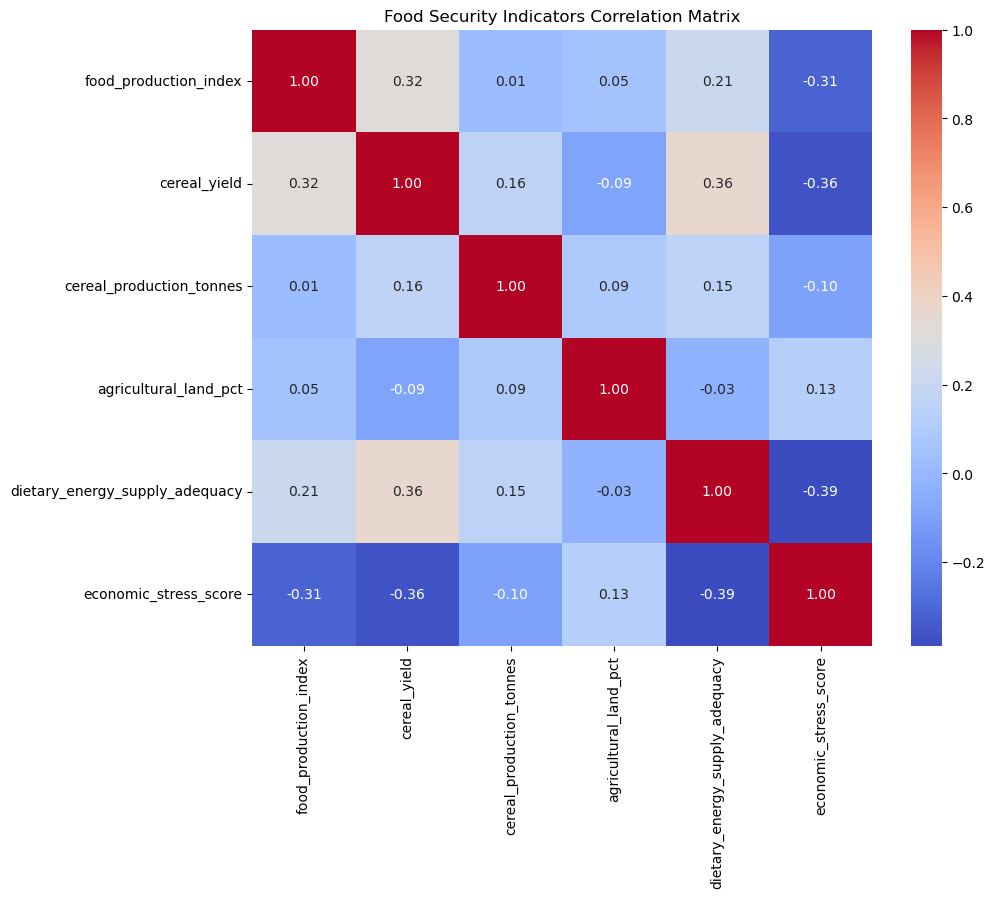

In [46]:
# =====================================================
# FOOD SECURITY HEATMAP
# =====================================================

plt.figure(figsize=(10,8))

sns.heatmap(
    food_corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title(
    'Food Security Indicators Correlation Matrix'
)

plt.show()

In [47]:
# =====================================================
# FOOD INDICATORS VS ECONOMIC STRESS
# =====================================================

food_corr[
    'economic_stress_score'
].sort_values(
    ascending=False
)

economic_stress_score             1.000000
agricultural_land_pct             0.125399
cereal_production_tonnes         -0.098303
food_production_index            -0.314729
cereal_yield                     -0.362638
dietary_energy_supply_adequacy   -0.387927
Name: economic_stress_score, dtype: float64

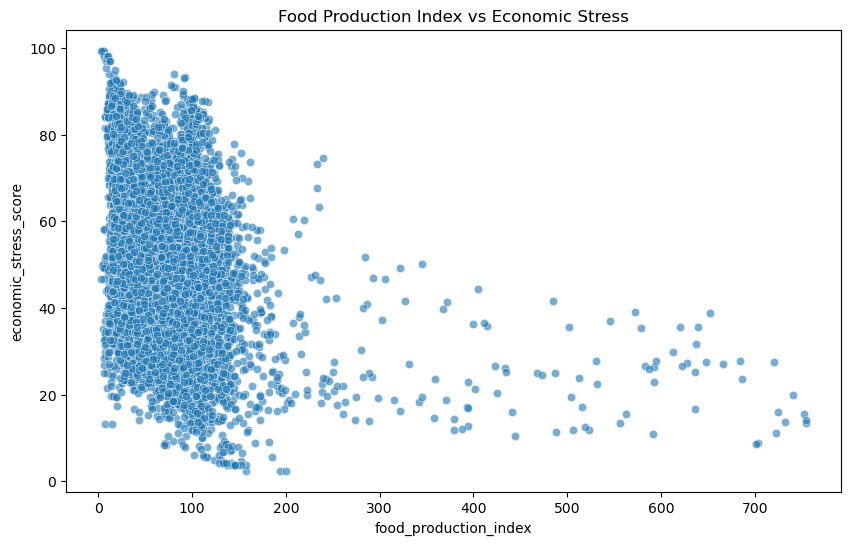

In [48]:
# =====================================================
# FOOD PRODUCTION VS STRESS
# =====================================================

plot_df = country_year[
    [
        'food_production_index',
        'economic_stress_score'
    ]
].dropna()

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=plot_df,
    x='food_production_index',
    y='economic_stress_score',
    alpha=0.6
)

plt.title(
    'Food Production Index vs Economic Stress'
)

plt.show()

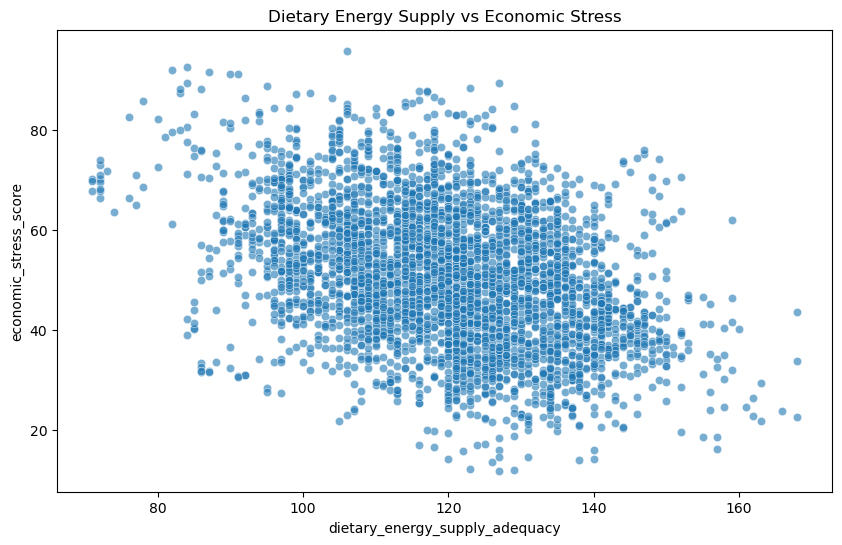

In [49]:
# =====================================================
# DIETARY ENERGY VS STRESS
# =====================================================

plot_df = country_year[
    [
        'dietary_energy_supply_adequacy',
        'economic_stress_score'
    ]
].dropna()

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=plot_df,
    x='dietary_energy_supply_adequacy',
    y='economic_stress_score',
    alpha=0.6
)

plt.title(
    'Dietary Energy Supply vs Economic Stress'
)

plt.show()

In [50]:
food_corr['economic_stress_score'].sort_values(
    ascending=False
)

economic_stress_score             1.000000
agricultural_land_pct             0.125399
cereal_production_tonnes         -0.098303
food_production_index            -0.314729
cereal_yield                     -0.362638
dietary_energy_supply_adequacy   -0.387927
Name: economic_stress_score, dtype: float64

### Key Findings

#### Food Security Indicators and Economic Stress

The analysis reveals that most food security indicators have a negative relationship with Economic Stress Score, suggesting that stronger food production and food availability are generally associated with lower economic stress.

#### Strongest Relationships

- Dietary Energy Supply Adequacy shows the strongest negative correlation with Economic Stress Score (-0.39).
- Cereal Yield also demonstrates a moderate negative relationship (-0.36).
- Food Production Index exhibits a negative correlation (-0.31).

These findings indicate that countries with stronger food availability and agricultural productivity tend to experience lower levels of economic stress.

#### Weak Relationships

- Cereal Production Tonnes shows only a weak negative relationship (-0.10).
- Agricultural Land Percentage exhibits a very weak positive relationship (0.13).

This suggests that simply having more agricultural land does not necessarily translate into lower economic stress. Productivity and food availability appear to be more important than land area alone.

#### Overall Conclusion

Food security indicators are important contributors to economic resilience. Countries with higher food production efficiency and better dietary energy availability generally experience lower levels of economic stress. Among all food-related indicators analyzed, Dietary Energy Supply Adequacy appears to be the strongest food security factor associated with reduced economic stress.

## 8. Economic Stress Driver Analysis

This section identifies the indicators most strongly associated with Economic Stress Score. The objective is to determine which economic and food security variables contribute most to economic vulnerability.

In [51]:
# =====================================================
# DRIVER ANALYSIS DATASET
# =====================================================

driver_cols = [
    'gdp_growth',
    'inflation',
    'unemployment',
    'gdp_per_capita',
    'population',
    'food_production_index',
    'cereal_yield',
    'cereal_production_tonnes',
    'agricultural_land_pct',
    'dietary_energy_supply_adequacy',
    'economic_stress_score'
]

driver_corr = country_year[
    driver_cols
].corr()

In [52]:
# =====================================================
# DRIVER RANKING
# =====================================================

stress_drivers = (
    driver_corr['economic_stress_score']
    .drop('economic_stress_score')
    .sort_values(
        key=abs,
        ascending=False
    )
)

stress_drivers

unemployment                      0.530306
gdp_growth                       -0.399189
dietary_energy_supply_adequacy   -0.387927
gdp_per_capita                   -0.369073
cereal_yield                     -0.362638
food_production_index            -0.314729
agricultural_land_pct             0.125399
cereal_production_tonnes         -0.098303
inflation                         0.093327
population                       -0.008932
Name: economic_stress_score, dtype: float64

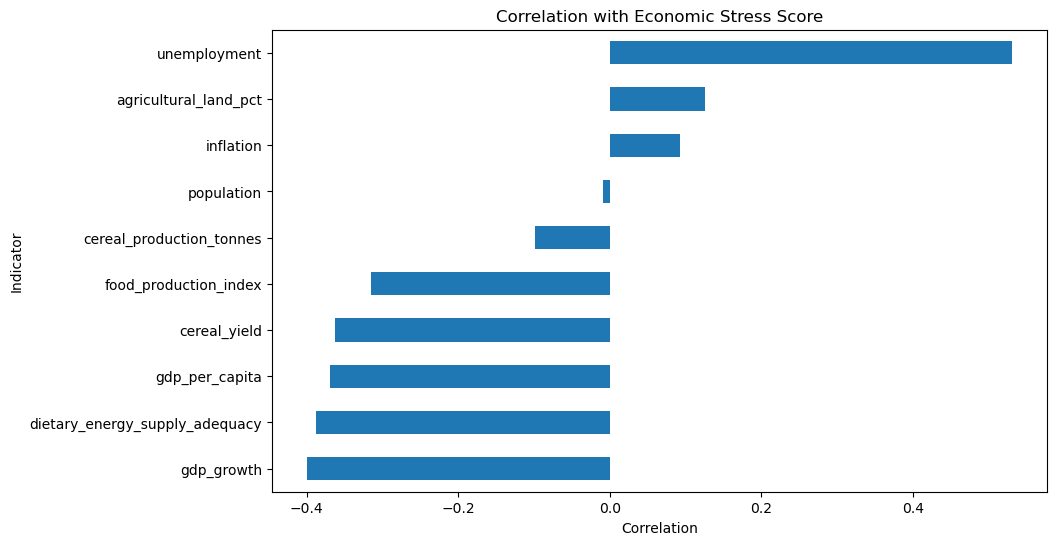

In [53]:
# =====================================================
# DRIVER ANALYSIS
# =====================================================

plt.figure(figsize=(10,6))

stress_drivers.sort_values().plot(
    kind='barh'
)

plt.title(
    'Correlation with Economic Stress Score'
)

plt.xlabel('Correlation')

plt.ylabel('Indicator')

plt.show()

### Key Findings

#### Strongest Positive Drivers of Economic Stress

Unemployment exhibits the strongest positive relationship with Economic Stress Score (0.53), indicating that countries with higher unemployment levels tend to experience substantially greater economic stress.

Agricultural Land Percentage shows a weak positive relationship (0.13), suggesting limited direct influence on economic stress levels.

Inflation (0.09) and Population (0.01) display very weak positive relationships, indicating minimal direct impact on overall economic stress within this dataset.

#### Strongest Negative Drivers of Economic Stress

GDP Growth demonstrates a moderate negative relationship (-0.40), indicating that stronger economic growth is associated with lower economic stress.

Dietary Energy Supply Adequacy (-0.39) is the second strongest negative driver, suggesting that improved food availability contributes significantly to economic resilience.

GDP per Capita (-0.37) and Cereal Yield (-0.36) also show meaningful negative relationships with economic stress, highlighting the importance of income levels and agricultural productivity.

Food Production Index (-0.31) further supports the conclusion that stronger food production systems contribute to lower economic vulnerability.

#### Overall Conclusion

The analysis indicates that economic stress is primarily influenced by labor market conditions, economic growth, income levels, and food security factors.

Among all variables analyzed:

- Unemployment is the strongest contributor to increased economic stress.
- GDP Growth is the strongest factor associated with reduced economic stress.
- Food security indicators collectively represent some of the most important protective factors against economic stress.

These findings suggest that policies aimed at employment generation, economic growth, and food security improvements may have the greatest impact on reducing economic vulnerability.